# NETAS 可解释性分析

这个 notebook 用于分析训练好的 `NETAS` checkpoint，包括：

- checkpoint 配置与测试指标
- basis kernel 形状与参数
- 事件 productivity (`eta`) 与 mixture weights (`omega`)
- 背景强度、触发强度和总强度分解
- 指定 forecast/query 时间的 top parent 贡献
- 最近历史截断参数对解释结果的影响

> 默认 checkpoint 指向 `checkpoints/netas_20260615-135518`。如果要分析其他 run，改下一节的 `CHECKPOINT_DIR` 即可。

In [1]:
from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import numpy as np
import pandas as pd
import torch

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "main.py").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Cannot find project root containing main.py and src/.")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("torch =", torch.__version__)
print("cuda available =", torch.cuda.is_available())

PROJECT_ROOT = /home/yzzhang/pjt/chuandian_eq
torch = 2.8.0+cu128
cuda available = True


## 1. 参数区

常用修改：

- `CHECKPOINT_DIR`：要分析的 checkpoint 目录
- `CKPT_SELECT`：`"best"` 或 `"last"`
- `SPLIT`：分析 `"train"` / `"val"` / `"test"`
- `SEQ_INDEX`：split 中第几个序列
- `QUERY_MODE`：`"nll_events"` 分析 NLL 事件；`"grid"` 分析连续时间网格

In [2]:
CHECKPOINT_DIR = Path("checkpoints/netas_20260615-135518")
CKPT_SELECT = "best"       # "best" or "last"
TRIAL_INDEX = 1

SPLIT = "test"             # "train", "val", or "test"
SEQ_INDEX = 0

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
FORCE_CPU = False
if FORCE_CPU:
    DEVICE = "cpu"

# 强度曲线配置
GRID_POINTS = 800
PLOT_LAST_DURATION = None   # None = plot full sequence; or set e.g. 10.0

# parent 贡献分析配置
QUERY_MODE = "nll_events"   # "nll_events" or "grid"
QUERY_EVENT_OFFSET = -1     # when QUERY_MODE="nll_events": -1 means last NLL event
QUERY_TIME = None           # when QUERY_MODE="grid": set a float, or None for sequence end
TOP_K_PARENTS = 20

# 为了避免解释时临时张量太大，可只分析最近历史；None 表示使用模型当前配置
EXPLAIN_MAX_HISTORY_EVENTS = None  # e.g. 4096
EXPLAIN_HISTORY_TIME_WINDOW = None # e.g. 30.0

CHECKPOINT_DIR = CHECKPOINT_DIR.resolve()
print("checkpoint_dir =", CHECKPOINT_DIR)
print("device =", DEVICE)

checkpoint_dir = /home/yzzhang/pjt/chuandian_eq/checkpoints/netas_20260615-135518
device = cuda:0


## 2. 加载 checkpoint、配置、数据和模型

这里复用项目的 `prepare_data_tpp` 和 `setup_config`，确保模型构建、catalog 统计量、checkpoint 权重加载方式与 `main.py --mode test` 一致。

In [3]:
from config import config_loader
import src.train.config_setup as config_setup
from src.data.batch import Batch
from src.data.preparation_modules.tpp import prepare_data_tpp


def checkpoint_path(checkpoint_dir: Path, select: str = "best", trial_index: int = 1) -> Path:
    if select not in {"best", "last"}:
        raise ValueError("select must be 'best' or 'last'.")
    return checkpoint_dir / f"{select}_model_{trial_index}.pth"


def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

ckpt_path = checkpoint_path(CHECKPOINT_DIR, CKPT_SELECT, TRIAL_INDEX)
config_path = CHECKPOINT_DIR / "config.yaml"
assert ckpt_path.exists(), ckpt_path
assert config_path.exists(), config_path

checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
args = config_loader.load_args_from_yaml(config_path)
args = config_setup.load_args_from_checkpoint(args, checkpoint)
args.model = str(args.model).lower()
args.minibatch_training = False
args.load_specific_parts = None
args.use_sampler = False
if getattr(args, "task_type", None) == "tpp" and getattr(args, "event_drop_prob", 0.0):
    args.event_drop_prob = 0.0

full_seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(args, f"data/{args.dataset}")
model, criterion, optimizer, scheduler, args = config_setup.setup_config(
    args,
    torch.device(DEVICE),
    train_dataloader=train_loader,
    checkpoint=checkpoint,
    restore_weights=True,
)
model.eval()

print("Loaded", ckpt_path)
print("model:", args.model)
print("dataset:", args.dataset)
print("catalog_cfg:", dict(getattr(args, "catalog_cfg", {}) or {}))
print("events train/val/test:", args.num_events_train, args.num_events_val, args.num_events_test)
print("basis:", model.basis.family, "num_basis=", model.num_basis)
print("history truncation: max_history_events=", getattr(model, "max_history_events", None),
      "history_time_window=", getattr(model, "history_time_window", None))

/opt/anaconda3/envs/fa_mamba_clean/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded /home/yzzhang/pjt/chuandian_eq/checkpoints/netas_20260615-135518/best_model_1.pth
model: netas
dataset: PNR_1z
catalog_cfg: {'freq': '1D', 'mag_completeness': -1.5}
events train/val/test: 3049 1204 850
basis: lomax num_basis= 20
history truncation: max_history_events= 0 history_time_window= None


## 3. 指标与超参数摘要

In [4]:
metrics = load_json_if_exists(CHECKPOINT_DIR / f"metrics_test_{CKPT_SELECT}_{TRIAL_INDEX}.json")
sliding_metrics = load_json_if_exists(CHECKPOINT_DIR / "sliding_window_eval_metrics.json")

if metrics is not None:
    display(pd.Series(metrics, name="value").to_frame())
else:
    print("No metrics_test json found.")

if sliding_metrics is not None:
    print("Sliding-window metrics:")
    display(pd.Series({k: v for k, v in sliding_metrics.items() if not isinstance(v, (dict, list))}, name="value").to_frame())

important_keys = [
    "netas_basis_family", "netas_num_basis", "netas_basis_lomax_shape",
    "netas_basis_rate_min", "netas_basis_rate_max", "netas_basis_scale_min", "netas_basis_scale_max",
    "netas_productivity_mode", "netas_productivity_alpha_init", "netas_productivity_bias_init",
    "bg_model", "fix_mu", "fixed_mu_value", "base_rate_init",
    "etas_query_chunk_size", "etas_history_chunk_size",
    "netas_max_history_events", "netas_history_time_window",
]
summary = {k: getattr(args, k, None) for k in important_keys}
display(pd.Series(summary, name="value").to_frame())

,value
nll_train_time,-6.087400e+00
nll_train_total,-6.103687e+00
nll_train_bg_norm,-8.143294e-02
nll_train_branching_penalty,3.152550e-07
nll_val_time,-6.612492e+00
nll_val_total,-6.639777e+00
nll_val_bg_norm,-1.373604e-01
nll_val_branching_penalty,1.866383e-04
nll_test_time,-6.414216e+00
nll_test_total,-6.427617e+00


Sliding-window metrics:


,value
status,ok
coverage,0.833333
mae,70.8529
rmse,181.131715
crps,60.630912
w95,220.948333
lp_nb,-4.754138
num_windows,30
sliding_cache_path,/root/autodl-tmp/em_eqf/checkpoints/netas_2026...
sliding_loaded_from_cache,False


,value
netas_basis_family,lomax
netas_num_basis,20
netas_basis_lomax_shape,0.56
netas_basis_rate_min,0.001
netas_basis_rate_max,10.0
netas_basis_scale_min,0.001
netas_basis_scale_max,100.0
netas_productivity_mode,softplus
netas_productivity_alpha_init,0.37
netas_productivity_bias_init,-0.6


## 4. 选择分析序列

`train/val/test` sequence 会保留历史上下文；例如 test sequence 通常包含从 catalog 起点到 test 结束的所有事件，但 NLL 只从 `t_nll_start` 开始。

In [5]:
def get_split_dataset(name: str):
    if name == "train":
        return catalog_ds.train
    if name == "val":
        return catalog_ds.val
    if name == "test":
        return catalog_ds.test
    raise ValueError("SPLIT must be one of train/val/test")

seq = get_split_dataset(SPLIT)[SEQ_INDEX]
print(f"split={SPLIT}, seq_index={SEQ_INDEX}")
print("num_events:", seq.num_events)
print("num_nll_events:", seq.num_nll_events)
print("t_start/t_nll_start/t_end:", seq.t_start, seq.t_nll_start, seq.t_end)
print("mag range:", float(seq.mag.min()), float(seq.mag.max()) if seq.num_events else None)

nll_mask_np = (seq.arrival_times >= seq.t_nll_start).cpu().numpy()
print("first/last arrival:", float(seq.arrival_times[0]), float(seq.arrival_times[-1]))
print("nll event time range:",
      float(seq.arrival_times[nll_mask_np][0]) if nll_mask_np.any() else None,
      float(seq.arrival_times[nll_mask_np][-1]) if nll_mask_np.any() else None)

split=test, seq_index=0
num_events: 6140
num_nll_events: 850
t_start/t_nll_start/t_end: 0.0 59.666666666666664 64.20832824707031
mag range: -1.4989999532699585 1.600000023841858
first/last arrival: 1.2314236164093018 64.16748809814453
nll event time range: 59.67906188964844 64.16748809814453


## 5. Basis kernel 形状

解释：`omega_{i,l}` 是事件 `i` 对第 `l` 个 basis 的权重；basis 曲线决定触发贡献随时间滞后 `lag=t-t_i` 如何衰减。

,basis,family,scale,shape
0,0,lomax,0.001000,0.56
1,1,lomax,0.001833,0.56
2,2,lomax,0.003360,0.56
3,3,lomax,0.006158,0.56
4,4,lomax,0.011288,0.56
5,5,lomax,0.020691,0.56
6,6,lomax,0.037927,0.56
7,7,lomax,0.069519,0.56
8,8,lomax,0.127428,0.56
9,9,lomax,0.233572,0.56


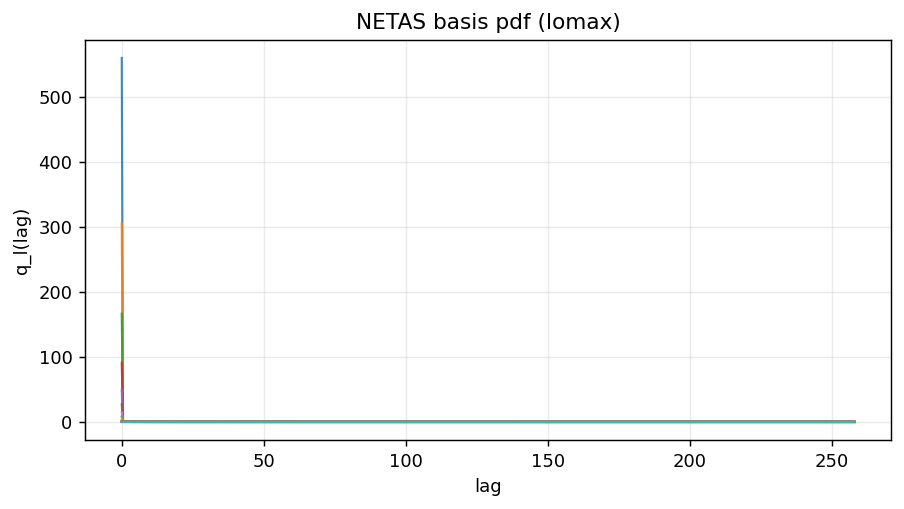

In [6]:
@torch.no_grad()
def basis_parameter_table(model) -> pd.DataFrame:
    basis = model.basis
    if basis.family == "exponential":
        rates = basis.effective_rates.detach().cpu().numpy()
        return pd.DataFrame({
            "basis": np.arange(len(rates)),
            "family": "exponential",
            "rate": rates,
            "time_scale_1/rate": 1.0 / rates,
        })
    scales = basis.effective_scales.detach().cpu().numpy()
    shapes = basis.effective_shapes.detach().cpu().numpy()
    return pd.DataFrame({
        "basis": np.arange(len(scales)),
        "family": "lomax",
        "scale": scales,
        "shape": shapes,
    })

@torch.no_grad()
def plot_basis_kernels(model, max_lag=None, n_grid=600):
    basis_df = basis_parameter_table(model)
    if max_lag is None:
        if model.basis.family == "exponential":
            max_lag = float(np.nanpercentile(basis_df["time_scale_1/rate"], 90) * 8)
        else:
            max_lag = float(np.nanpercentile(basis_df["scale"], 90) * 8)
        max_lag = max(max_lag, 1e-3)
    lag = torch.linspace(0.0, max_lag, n_grid, device=model.device)
    pdf = model.basis.pdf(lag).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(8, 4))
    for idx in range(pdf.shape[-1]):
        ax.plot(lag.cpu().numpy(), pdf[:, idx], lw=1.2, alpha=0.85, label=f"basis {idx}")
    ax.set_title(f"NETAS basis pdf ({model.basis.family})")
    ax.set_xlabel("lag")
    ax.set_ylabel("q_l(lag)")
    if pdf.shape[-1] <= 12:
        ax.legend(ncol=2, fontsize=8)
    ax.grid(alpha=0.25)
    return basis_df, fig

basis_df, fig = plot_basis_kernels(model)
display(basis_df)
plt.show()

## 6. Parent 参数：productivity 与 mixture weights

- `eta_i`：事件 `i` 的总触发生产率
- `omega_{i,l}`：事件 `i` 在不同 basis 上的分布
- `eta_i * omega_{i,l}`：事件 `i` 对各 basis 的有效触发强度权重

,event_idx,time,mag,eta,dominant_basis,dominant_omega,is_nll_event
count,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140
unique,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,5290
mean,3069.500000,26.108648,-1.156967,0.965137,0.293322,0.617342,NaN
std,1772.609658,23.615217,0.303737,0.250881,1.445245,0.287458,NaN
min,0.000000,1.231424,-1.499000,0.363691,0.000000,0.052733,NaN
25%,1534.750000,10.147636,-1.385000,0.778714,0.000000,0.373184,NaN
50%,3069.500000,11.451852,-1.239000,1.027527,0.000000,0.767474,NaN
75%,4604.250000,57.082899,-1.007000,1.142222,0.000000,0.844714,NaN


,event_idx,time,mag,eta,dominant_basis,dominant_omega,is_nll_event,omega_0,omega_1,omega_2,omega_3,omega_4,omega_5,omega_6,omega_7,omega_8,omega_9,omega_10,omega_11,omega_12,omega_13,omega_14,omega_15,omega_16,omega_17,omega_18,omega_19
6120,6120,63.803425,-1.334,0.547623,0,0.101723,True,0.101723,0.061536,0.052480,0.046314,0.044722,0.043675,0.042458,0.041525,0.041710,0.043226,0.046348,0.050712,0.056112,0.058480,0.053249,0.047676,0.044525,0.041858,0.041216,0.040454
6121,6121,63.805058,-1.171,0.601771,0,0.123715,True,0.123715,0.067153,0.054730,0.046093,0.043691,0.041966,0.040254,0.037534,0.038363,0.040089,0.043935,0.048883,0.055423,0.058448,0.052463,0.046453,0.042814,0.039974,0.039339,0.038680
6122,6122,63.809513,-0.944,0.669238,0,0.147999,True,0.147999,0.070083,0.054562,0.044454,0.041541,0.039715,0.037898,0.034634,0.035819,0.037626,0.042338,0.048044,0.056275,0.059794,0.052378,0.045266,0.040929,0.037578,0.036878,0.036189
6123,6123,63.813763,-1.134,0.632998,0,0.149525,True,0.149525,0.070045,0.054240,0.044255,0.041275,0.039486,0.037684,0.034537,0.035602,0.037600,0.042185,0.048166,0.056457,0.060011,0.052529,0.045271,0.040907,0.037442,0.036760,0.036025
6124,6124,63.815254,-1.216,0.632795,0,0.166441,True,0.166441,0.073553,0.055405,0.043966,0.040510,0.038319,0.036237,0.032200,0.033469,0.035683,0.040364,0.046686,0.055312,0.059295,0.051620,0.044281,0.039770,0.036290,0.035641,0.034956
6125,6125,63.838161,-0.816,0.708261,0,0.165340,True,0.165340,0.070048,0.052848,0.042538,0.039451,0.037852,0.036185,0.033213,0.034424,0.036394,0.041657,0.048141,0.057889,0.061777,0.052851,0.044622,0.039679,0.035840,0.034994,0.034256
6126,6126,63.838982,-1.465,0.579174,0,0.158034,True,0.158034,0.072726,0.055459,0.044525,0.041160,0.038993,0.036935,0.033045,0.034119,0.036498,0.040773,0.047113,0.055144,0.059021,0.051837,0.044774,0.040474,0.037111,0.036483,0.035778
6127,6127,63.887165,-1.394,0.552664,0,0.119993,True,0.119993,0.064601,0.052765,0.045403,0.043008,0.041550,0.040207,0.038632,0.039032,0.041094,0.044638,0.049944,0.056814,0.059897,0.053478,0.047100,0.043333,0.040253,0.039494,0.038764
6128,6128,63.888161,-1.281,0.601757,0,0.147219,True,0.147219,0.071437,0.055708,0.045187,0.042041,0.039850,0.037882,0.034228,0.035291,0.037455,0.041610,0.047410,0.054965,0.058775,0.051993,0.045343,0.041235,0.038127,0.037437,0.036807
6129,6129,63.888439,-1.399,0.627321,0,0.202654,True,0.202654,0.080878,0.057865,0.043335,0.038919,0.035854,0.033322,0.027780,0.029393,0.031859,0.036591,0.043239,0.052235,0.057016,0.049335,0.042039,0.037373,0.033984,0.033442,0.032885


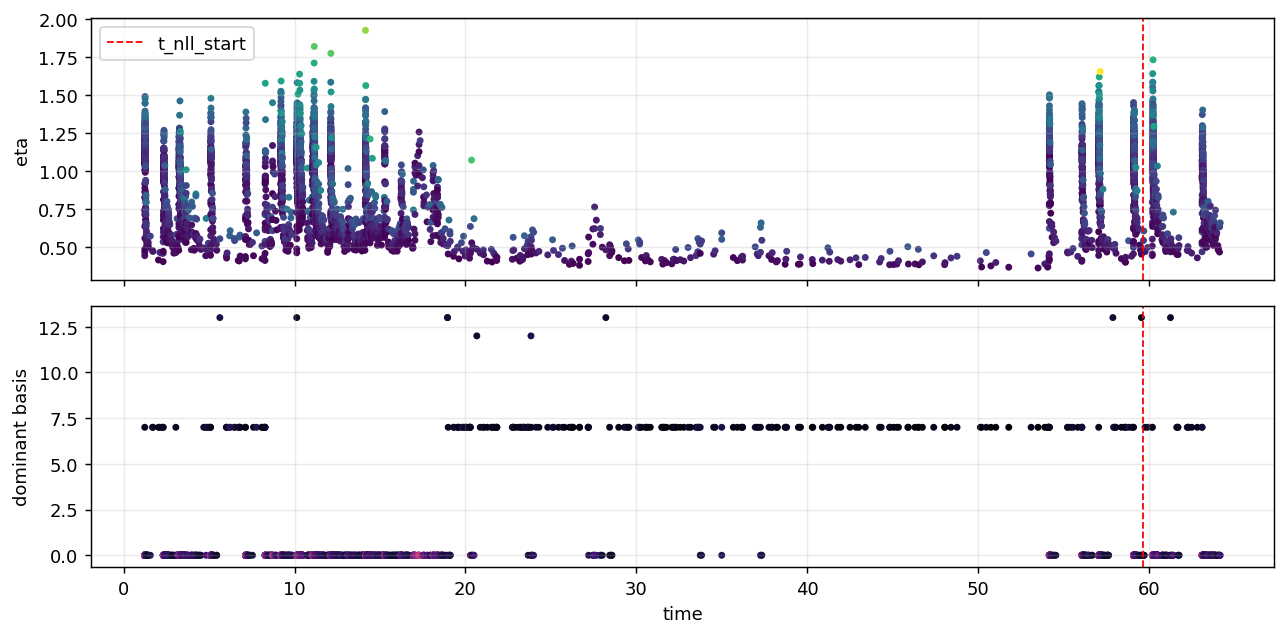

In [7]:
@torch.no_grad()
def parent_parameter_frame(model, seq) -> tuple[pd.DataFrame, dict[str, torch.Tensor]]:
    batch = Batch.from_list([seq]).to(model.device)
    parent_params = model.parent_parameters(batch)
    eta = parent_params["eta"][0].detach().cpu()
    omega = parent_params["omega"][0].detach().cpu()
    event_mask = parent_params["event_mask"][0].bool().detach().cpu()
    times = seq.arrival_times.detach().cpu()
    mags = seq.mag.detach().cpu()
    rows = []
    valid_indices = torch.where(event_mask[: seq.num_events])[0]
    for idx in valid_indices.tolist():
        row = {
            "event_idx": idx,
            "time": float(times[idx]),
            "mag": float(mags[idx]),
            "eta": float(eta[idx]),
            "dominant_basis": int(torch.argmax(omega[idx]).item()),
            "dominant_omega": float(torch.max(omega[idx]).item()),
            "is_nll_event": bool(times[idx] >= seq.t_nll_start),
        }
        for b in range(omega.shape[-1]):
            row[f"omega_{b}"] = float(omega[idx, b])
        rows.append(row)
    return pd.DataFrame(rows), parent_params

parent_df, parent_params = parent_parameter_frame(model, seq)
display(parent_df[["event_idx", "time", "mag", "eta", "dominant_basis", "dominant_omega", "is_nll_event"]].describe(include="all"))
display(parent_df.tail(20))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].scatter(parent_df["time"], parent_df["eta"], s=8, c=parent_df["mag"], cmap="viridis")
axes[0].axvline(seq.t_nll_start, color="r", ls="--", lw=1, label="t_nll_start")
axes[0].set_ylabel("eta")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].scatter(parent_df["time"], parent_df["dominant_basis"], s=8, c=parent_df["eta"], cmap="magma")
axes[1].axvline(seq.t_nll_start, color="r", ls="--", lw=1)
axes[1].set_ylabel("dominant basis")
axes[1].set_xlabel("time")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. 强度分解：background / trigger / total

这部分在网格上计算：

```text
total_intensity = trigger_intensity + mu + bg_model_intensity
```

如果模型没有 `bg_model`，背景外生项只有 `mu`。

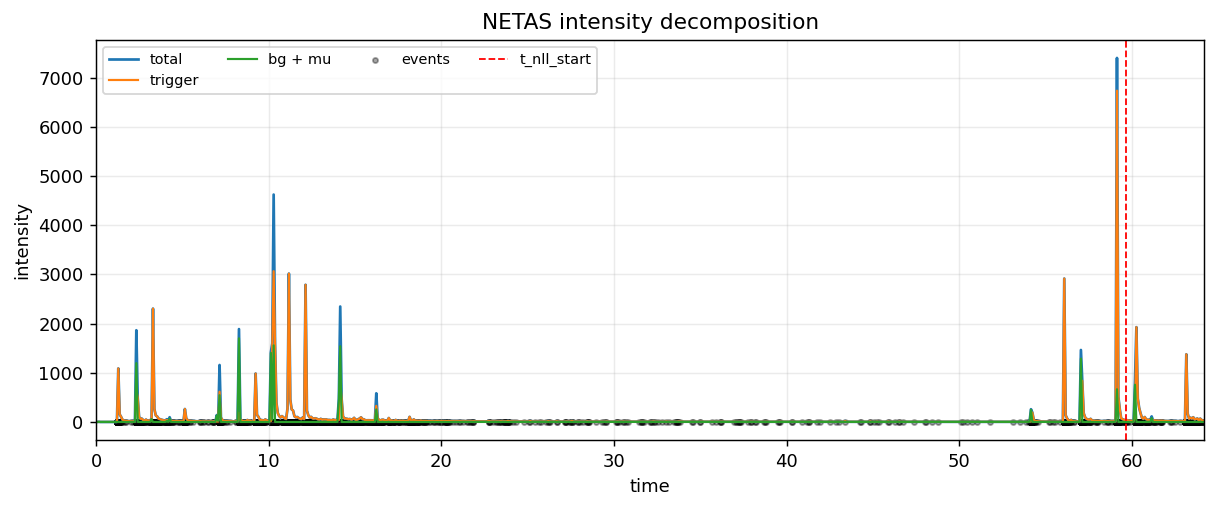

,trigger,mu,bg,total
count,800.000000,800.0,800.000000,800.000000
mean,66.455078,0.0,15.030841,81.485916
std,353.194794,0.0,133.411453,414.318970
min,0.000000,0.0,0.000000,0.000000
25%,4.613729,0.0,0.000000,4.613729
50%,10.083121,0.0,0.000000,10.149861
75%,26.751125,0.0,0.000000,27.839449
max,6735.212891,0.0,1700.220337,7399.618164


In [8]:
@torch.no_grad()
def make_plot_grid(seq, n_points=800, last_duration=None, device=None):
    end = float(seq.t_end)
    start = float(seq.t_start if last_duration is None else max(seq.t_start, end - float(last_duration)))
    return torch.linspace(start, end, int(n_points), device=device).unsqueeze(0)

@torch.no_grad()
def intensity_decomposition(model, seq, grid):
    batch = Batch.from_list([seq]).to(model.device)
    parent_params = model.parent_parameters(batch)
    trigger = model.trigger_intensity(batch, t_query=grid, parent_params=parent_params)
    mu = torch.full_like(trigger, float(model.mu.detach().cpu().item()))
    bg = torch.zeros_like(trigger)
    if getattr(model, "bg_model", None) is not None:
        if hasattr(model.bg_model, "cache_batch") and hasattr(seq, "time_series") and hasattr(seq, "time_series_times"):
            model.bg_model.cache_batch(seq.time_series.unsqueeze(0).to(model.device), seq.time_series_times.unsqueeze(0).to(model.device))
        bg = model.bg_model.intensity(batch, t_query=grid)
    total = trigger + mu + bg
    return {
        "grid": grid.squeeze(0).detach().cpu().numpy(),
        "trigger": trigger.squeeze(0).detach().cpu().numpy(),
        "mu": mu.squeeze(0).detach().cpu().numpy(),
        "bg": bg.squeeze(0).detach().cpu().numpy(),
        "total": total.squeeze(0).detach().cpu().numpy(),
    }

grid = make_plot_grid(seq, GRID_POINTS, PLOT_LAST_DURATION, model.device)
dec = intensity_decomposition(model, seq, grid)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dec["grid"], dec["total"], label="total", lw=1.5)
ax.plot(dec["grid"], dec["trigger"], label="trigger", lw=1.2)
ax.plot(dec["grid"], dec["bg"] + dec["mu"], label="bg + mu", lw=1.2)
ax.scatter(seq.arrival_times.cpu().numpy(), np.zeros(seq.num_events), s=8, c="k", alpha=0.35, label="events")
ax.axvline(seq.t_nll_start, color="r", ls="--", lw=1, label="t_nll_start")
ax.set_xlim(dec["grid"].min(), dec["grid"].max())
ax.set_xlabel("time")
ax.set_ylabel("intensity")
ax.set_title("NETAS intensity decomposition")
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.25)
plt.show()

pd.DataFrame({k: v for k, v in dec.items() if k != "grid"}).describe()

## 8. 单个 query 时间的 top parent 贡献

对指定 query 时间 `t_q`，分解每个历史事件对触发强度的贡献：

```text
contribution_i(t_q) = eta_i * sum_l omega_{i,l} q_l(t_q - t_i)
```

这能回答：当前强度主要由哪些历史事件触发？它们的滞后时间、震级、eta、basis 权重如何？

query_time = 64.16748809814453
num valid parents = 6139


,event_idx,event_time,query_time,lag,mag,eta,contribution,dominant_basis,basis_contrib_0,basis_contrib_1,basis_contrib_2,basis_contrib_3,basis_contrib_4,basis_contrib_5,basis_contrib_6,basis_contrib_7,basis_contrib_8,basis_contrib_9,basis_contrib_10,basis_contrib_11,basis_contrib_12,basis_contrib_13,basis_contrib_14,basis_contrib_15,basis_contrib_16,basis_contrib_17,basis_contrib_18,basis_contrib_19,contribution_frac
0,6138,64.132591,64.167488,0.034897,-0.901,0.634197,1.301773,5,0.142737,0.113424,0.126392,0.138154,0.155521,0.159262,0.142305,0.109809,0.078717,0.051767,0.033815,0.021213,0.013361,0.007716,0.003845,0.001882,0.000957,0.000492,0.000264,0.000142,0.051376
1,6137,64.128319,64.167488,0.039169,-0.712,0.642092,1.182812,5,0.099424,0.090223,0.106370,0.122000,0.141792,0.149586,0.138529,0.113346,0.081993,0.054280,0.035000,0.021585,0.013275,0.007629,0.003878,0.001941,0.001004,0.000524,0.000281,0.000151,0.046681
2,6136,64.124825,64.167488,0.042664,-1.456,0.468572,0.803496,5,0.043698,0.049990,0.064206,0.080257,0.096886,0.105538,0.101569,0.090466,0.064641,0.043118,0.026626,0.016026,0.009365,0.005316,0.002809,0.001454,0.000775,0.000413,0.000223,0.000120,0.031711
3,6135,64.060509,64.167488,0.106979,-1.420,0.491437,0.346399,7,0.013243,0.013960,0.017810,0.022662,0.029433,0.036226,0.041262,0.043876,0.038941,0.031200,0.022237,0.014816,0.009292,0.005484,0.002904,0.001496,0.000791,0.000420,0.000226,0.000122,0.013671
4,6134,64.045937,64.167488,0.121552,-1.480,0.483027,0.300208,7,0.010922,0.011206,0.014241,0.018219,0.023825,0.029806,0.034663,0.038093,0.034723,0.028746,0.021006,0.014334,0.009135,0.005432,0.002868,0.001469,0.000774,0.000409,0.000220,0.000118,0.011848
5,6133,64.027451,64.167488,0.140038,-1.397,0.511044,0.272230,7,0.010845,0.009865,0.012090,0.015210,0.019814,0.025105,0.029707,0.033346,0.031532,0.027191,0.020809,0.014797,0.009824,0.005926,0.003072,0.001541,0.000799,0.000415,0.000223,0.000119,0.010744
6,6132,63.966736,64.167488,0.200752,-1.183,0.594574,0.211072,8,0.010753,0.007541,0.008433,0.009896,0.012665,0.016181,0.019603,0.022011,0.023043,0.022032,0.019068,0.015029,0.011006,0.006951,0.003507,0.001704,0.000858,0.000434,0.000232,0.000124,0.008330
7,6130,63.891769,64.167488,0.275719,-0.994,0.743908,0.164389,0,0.016468,0.007355,0.006838,0.006794,0.008174,0.010059,0.011985,0.011930,0.014098,0.015008,0.015231,0.013755,0.011635,0.007882,0.003814,0.001765,0.000846,0.000412,0.000221,0.000119,0.006488
8,6131,63.927128,64.167488,0.240360,-1.465,0.579241,0.163864,9,0.010332,0.006129,0.006381,0.007116,0.008894,0.011261,0.013677,0.015016,0.016511,0.016803,0.015502,0.013083,0.010174,0.006616,0.003303,0.001576,0.000782,0.000388,0.000209,0.000111,0.006467
9,6128,63.888161,64.167488,0.279327,-1.281,0.601757,0.149471,9,0.007537,0.005111,0.005549,0.006223,0.007906,0.010012,0.012248,0.013399,0.015264,0.015841,0.014961,0.012660,0.009763,0.006420,0.003321,0.001643,0.000833,0.000425,0.000229,0.000123,0.005899


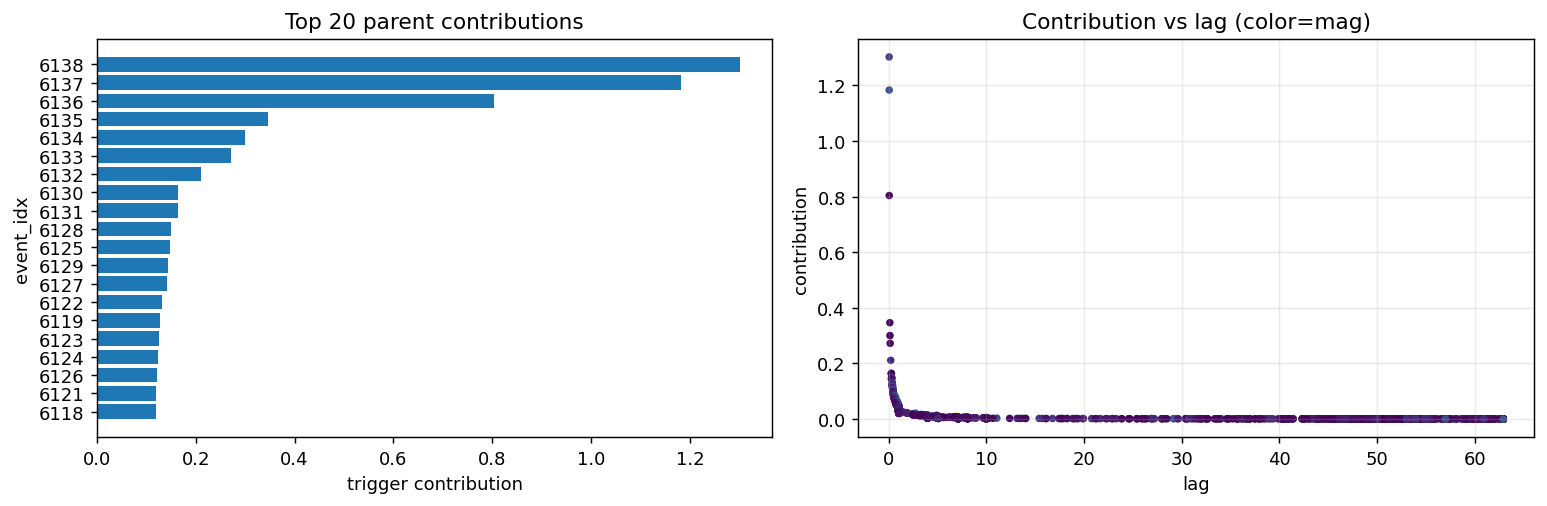

In [9]:
def resolve_query_time(seq, mode="nll_events", offset=-1, query_time=None):
    if mode == "grid":
        return float(seq.t_end if query_time is None else query_time)
    nll_times = seq.arrival_times[seq.arrival_times >= seq.t_nll_start]
    if nll_times.numel() == 0:
        raise ValueError("No NLL events in selected sequence.")
    return float(nll_times[int(offset)].item())

@torch.no_grad()
def parent_contribution_frame(
    model,
    seq,
    query_time: float,
    *,
    max_history_events=None,
    history_time_window=None,
) -> pd.DataFrame:
    old_max = getattr(model, "max_history_events", 0)
    old_window = getattr(model, "history_time_window", None)
    if max_history_events is not None:
        model.max_history_events = int(max_history_events)
    if history_time_window is not None:
        model.history_time_window = None if float(history_time_window) == 0 else float(history_time_window)
    try:
        batch = Batch.from_list([seq]).to(model.device)
        parent_params = model.parent_parameters(batch)
        t_history = batch.arrival_times[0]
        event_mask = parent_params["event_mask"][0].bool()
        eta = parent_params["eta"][0]
        omega = parent_params["omega"][0]
        t_query = torch.tensor(float(query_time), device=model.device, dtype=t_history.dtype)
        delta_t = t_query - t_history
        valid = event_mask & (delta_t > 0)
        if model.history_time_window is not None:
            valid = valid & (delta_t <= float(model.history_time_window))
        valid_indices = torch.where(valid)[0]
        if model.max_history_events > 0 and valid_indices.numel() > model.max_history_events:
            valid_indices = valid_indices[-model.max_history_events:]
        if valid_indices.numel() == 0:
            return pd.DataFrame()
        dt = delta_t[valid_indices]
        basis_pdf = model.basis.pdf(dt)
        weighted_basis = eta[valid_indices].unsqueeze(-1) * omega[valid_indices] * basis_pdf
        contrib = weighted_basis.sum(dim=-1)
        rows = []
        for local, idx in enumerate(valid_indices.tolist()):
            row = {
                "event_idx": idx,
                "event_time": float(t_history[idx].detach().cpu()),
                "query_time": float(query_time),
                "lag": float(dt[local].detach().cpu()),
                "mag": float(batch.mag[0, idx].detach().cpu()),
                "eta": float(eta[idx].detach().cpu()),
                "contribution": float(contrib[local].detach().cpu()),
                "dominant_basis": int(torch.argmax(weighted_basis[local]).detach().cpu()),
            }
            for b in range(weighted_basis.shape[-1]):
                row[f"basis_contrib_{b}"] = float(weighted_basis[local, b].detach().cpu())
            rows.append(row)
        df = pd.DataFrame(rows).sort_values("contribution", ascending=False).reset_index(drop=True)
        df["contribution_frac"] = df["contribution"] / df["contribution"].sum()
        return df
    finally:
        model.max_history_events = old_max
        model.history_time_window = old_window

query_time = resolve_query_time(seq, QUERY_MODE, QUERY_EVENT_OFFSET, QUERY_TIME)
contrib_df = parent_contribution_frame(
    model,
    seq,
    query_time,
    max_history_events=EXPLAIN_MAX_HISTORY_EVENTS,
    history_time_window=EXPLAIN_HISTORY_TIME_WINDOW,
)
print("query_time =", query_time)
print("num valid parents =", len(contrib_df))
display(contrib_df.head(TOP_K_PARENTS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = contrib_df.head(TOP_K_PARENTS).iloc[::-1]
axes[0].barh(plot_df["event_idx"].astype(str), plot_df["contribution"])
axes[0].set_title(f"Top {TOP_K_PARENTS} parent contributions")
axes[0].set_xlabel("trigger contribution")
axes[0].set_ylabel("event_idx")
axes[1].scatter(contrib_df["lag"], contrib_df["contribution"], s=10, c=contrib_df["mag"], cmap="viridis")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("contribution")
axes[1].set_title("Contribution vs lag (color=mag)")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Basis-level 贡献热图

对 top parents，查看每个 basis 对贡献的分解。用于判断模型在当前 query 处依赖短期核还是长期核。

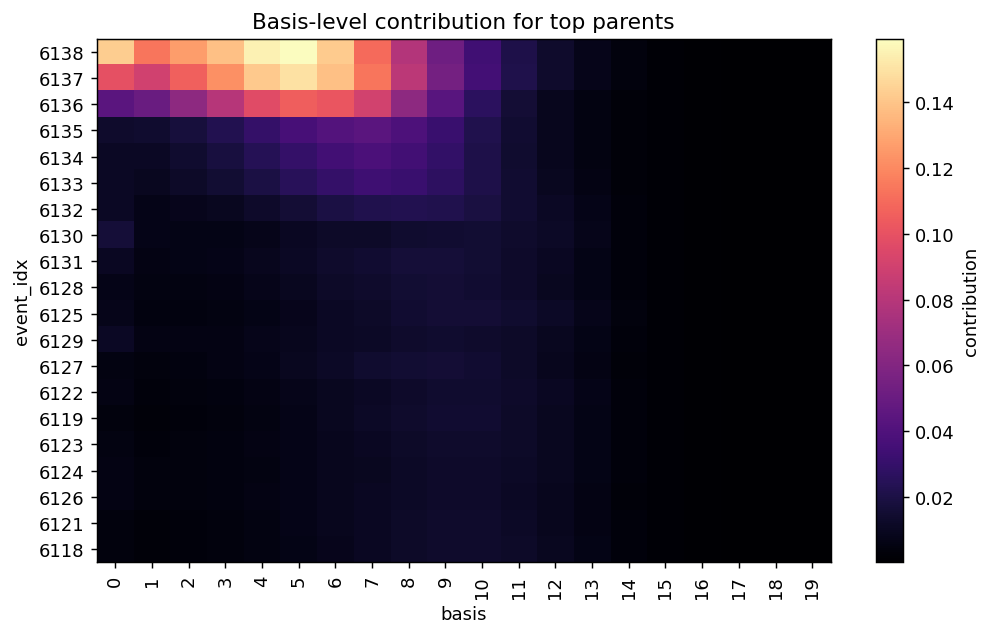

In [10]:
basis_cols = [c for c in contrib_df.columns if c.startswith("basis_contrib_")]
if len(contrib_df) and basis_cols:
    heat_df = contrib_df.head(TOP_K_PARENTS).set_index("event_idx")[basis_cols]
    fig, ax = plt.subplots(figsize=(max(8, len(basis_cols) * 0.4), 5))
    im = ax.imshow(heat_df.values, aspect="auto", cmap="magma")
    ax.set_yticks(np.arange(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index.astype(str))
    ax.set_xticks(np.arange(len(basis_cols)))
    ax.set_xticklabels([c.replace("basis_contrib_", "") for c in basis_cols], rotation=90)
    ax.set_xlabel("basis")
    ax.set_ylabel("event_idx")
    ax.set_title("Basis-level contribution for top parents")
    fig.colorbar(im, ax=ax, label="contribution")
    plt.tight_layout()
    plt.show()
else:
    print("No contribution rows available.")

## 10. 历史截断敏感性分析

比较不同 `max_history_events` 下，同一个 query 时间的 trigger 强度保留比例。可以用来选择近似截断长度。

,max_history_events,trigger,fraction_of_full
0,0,25.338024,1.000000
1,128,11.763502,0.464263
2,256,14.943827,0.589779
3,512,17.467588,0.689382
4,1024,20.250437,0.799211
5,2048,23.747971,0.937246
6,4096,24.698505,0.974761


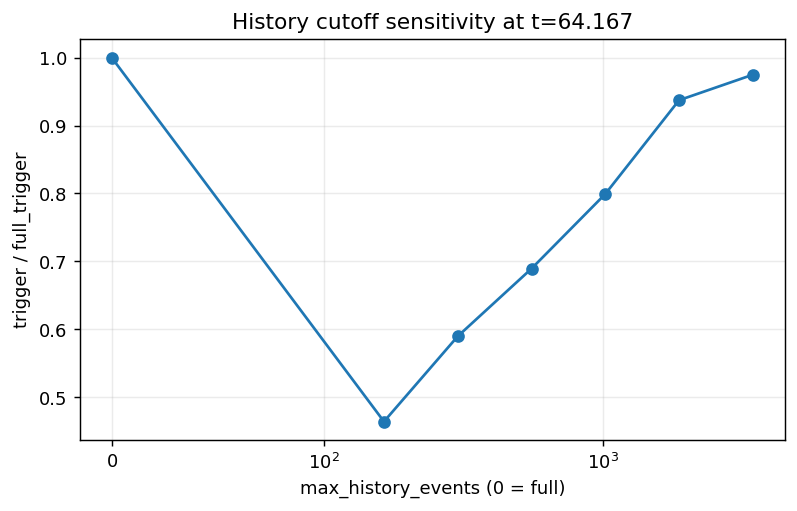

In [11]:
@torch.no_grad()
def trigger_at_query_with_history_cap(model, seq, query_time, cap):
    old_cap = getattr(model, "max_history_events", 0)
    old_window = getattr(model, "history_time_window", None)
    model.max_history_events = int(cap or 0)
    model.history_time_window = None
    try:
        batch = Batch.from_list([seq]).to(model.device)
        parent_params = model.parent_parameters(batch)
        tq = torch.tensor([[float(query_time)]], device=model.device, dtype=batch.arrival_times.dtype)
        return float(model.trigger_intensity(batch, t_query=tq, parent_params=parent_params).squeeze().detach().cpu())
    finally:
        model.max_history_events = old_cap
        model.history_time_window = old_window

caps = [0, 128, 256, 512, 1024, 2048, 4096, 8192]
rows = []
full_value = trigger_at_query_with_history_cap(model, seq, query_time, 0)
for cap in caps:
    if cap > seq.num_events:
        continue
    value = trigger_at_query_with_history_cap(model, seq, query_time, cap)
    rows.append({
        "max_history_events": cap,
        "trigger": value,
        "fraction_of_full": value / full_value if full_value != 0 else np.nan,
    })
cap_df = pd.DataFrame(rows)
display(cap_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cap_df["max_history_events"], cap_df["fraction_of_full"], marker="o")
ax.set_xscale("symlog", linthresh=128)
ax.set_xlabel("max_history_events (0 = full)")
ax.set_ylabel("trigger / full_trigger")
ax.set_title(f"History cutoff sensitivity at t={query_time:.3f}")
ax.grid(alpha=0.25)
plt.show()

## 11. 保存解释结果

默认保存为 CSV，便于和其他模型/窗口比较。

In [ ]:
OUT_DIR = CHECKPOINT_DIR / "netas_interpretability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

parent_path = OUT_DIR / f"{SPLIT}_seq{SEQ_INDEX}_parent_params.csv"
contrib_path = OUT_DIR / f"{SPLIT}_seq{SEQ_INDEX}_query_{query_time:.6f}_parent_contrib.csv"
cap_path = OUT_DIR / f"{SPLIT}_seq{SEQ_INDEX}_query_{query_time:.6f}_history_cap_sensitivity.csv"

# parent_df.to_csv(parent_path, index=False)
# contrib_df.to_csv(contrib_path, index=False)
# cap_df.to_csv(cap_path, index=False)

print("saved:")
print(parent_path)
print(contrib_path)
print(cap_path)

saved:
/root/autodl-tmp/em_eqf/checkpoints/netas_20260615-135518/netas_interpretability/test_seq0_parent_params.csv
/root/autodl-tmp/em_eqf/checkpoints/netas_20260615-135518/netas_interpretability/test_seq0_query_64.167488_parent_contrib.csv
/root/autodl-tmp/em_eqf/checkpoints/netas_20260615-135518/netas_interpretability/test_seq0_query_64.167488_history_cap_sensitivity.csv
